# PyTorch: From Basics to Expert — A Hands-On Notebook

Welcome! This notebook teaches **PyTorch** end-to-end, assuming you already know machine-learning concepts (models, loss, gradients) but are **new to PyTorch**. The goal is to teach you *the PyTorch way of thinking*, not just syntax.

**What you will build along the way**
- Solid command of **tensors** and **autograd** (the two ideas everything rests on)
- A linear-regression model **from scratch**, then rebuilt **the idiomatic way** with `nn.Module` + optimizers
- `Dataset` / `DataLoader` pipelines
- A real **MLP classifier** with regularization and a decision-boundary plot
- A **CNN** for image classification (computer vision)
- **RNN & LSTM** models for sequences, plus a time-series forecaster that predicts the future of a signal
- A **Transformer language model written from scratch** (NLP) that actually generates text
- **Expert** topics: schedulers, gradient clipping/accumulation, mixed precision, custom layers, custom `autograd.Function`, `torch.compile`, profiling, and **deployment** (TorchScript + ONNX)

**How to use this notebook**
- Run cells top to bottom (`Shift+Enter`). Each section builds on the previous one.
- 🧪 *Try it* prompts invite you to tweak a number and re-run.
- ⚠️ Boxes flag the classic gotchas that trip up newcomers.
- 🖥️ **GPU note** boxes mark code whose benefit only shows up on a CUDA GPU — it still *runs* on CPU.

> This notebook is written to run on **CPU** (no GPU required). Models and datasets are deliberately tiny so everything trains in seconds.

---

### Table of contents
1. Tensors — the core data structure
2. Autograd — automatic differentiation
3. Linear regression **from scratch** (autograd only)
4. The idiomatic way: `nn.Module`, losses, optimizers
5. `Dataset` & `DataLoader`
6. A real classifier (MLP) + regularization
7. Computer vision: a CNN
8. Saving & loading models
9. Sequence models: RNNs & LSTMs
10. NLP: a Transformer **from scratch**
11. Expert techniques (schedulers, AMP, custom ops, profiling…)
12. Deployment (TorchScript & ONNX)
13. Exercises & where to go next

## 0. Setup

Imports, version check, a **device helper**, and a **seed helper** for reproducibility. Re-run this cell first whenever you restart the kernel.

In [1]:
import math, time, warnings
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")          # keep the notebook output clean
torch.set_printoptions(precision=3, sci_mode=False)
%matplotlib inline

print("PyTorch :", torch.__version__)
print("NumPy   :", np.__version__)

def get_device():
    """Pick the best available device. On this machine it will be CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")          # Apple Silicon
    return torch.device("cpu")

def set_seed(seed=42):
    """Seed Python/NumPy/PyTorch so results are repeatable."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = get_device()
set_seed(42)
print("Device  :", device)

PyTorch : 2.4.1+cpu
NumPy   : 2.3.1
Device  : cpu


## 1. Tensors — the core data structure

A **tensor** is PyTorch's n-dimensional array. If you know NumPy, you already know 90% of it: a `torch.Tensor` is to PyTorch what `ndarray` is to NumPy. The two extra superpowers that make tensors special:

1. They can live on a **GPU** (`.to("cuda")`).
2. They can **track gradients** for automatic differentiation (next section).

Mental model: *a tensor is a typed, multi-dimensional array that optionally remembers how it was computed so PyTorch can differentiate through it.*

### 1.1 Creating tensors

There are three families of constructors you will use constantly:
- **From data**: `torch.tensor([...])`
- **By shape**: `torch.zeros`, `torch.ones`, `torch.empty`, `torch.full`
- **Random / ranges**: `torch.rand`, `torch.randn`, `torch.arange`, `torch.linspace`

In [2]:
# From Python data (dtype is inferred)
a = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])
print("a =\n", a, "| dtype:", a.dtype)          # int64

# Floats: note the decimal points
b = torch.tensor([1.0, 2.0, 3.0])
print("b dtype:", b.dtype)                       # float32 (PyTorch's default float)

# By shape
print("zeros:\n", torch.zeros(2, 3))
print("ones :\n", torch.ones(2, 3))
print("full :\n", torch.full((2, 2), 7.0))

# Random and ranges (set_seed above makes these reproducible)
print("randn (std normal):\n", torch.randn(2, 3))
print("arange:", torch.arange(0, 10, 2))         # like Python range
print("linspace:", torch.linspace(0, 1, 5))      # 5 evenly spaced points

# "*_like" copies the shape/dtype/device of another tensor
print("zeros_like(a):\n", torch.zeros_like(a))

a =
 tensor([[1, 2, 3],
        [4, 5, 6]]) | dtype: torch.int64
b dtype: torch.float32
zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones :
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
full :
 tensor([[7., 7.],
        [7., 7.]])
randn (std normal):
 tensor([[ 0.337,  0.129,  0.234],
        [ 0.230, -1.123, -0.186]])
arange: tensor([0, 2, 4, 6, 8])
linspace: tensor([0.000, 0.250, 0.500, 0.750, 1.000])
zeros_like(a):
 tensor([[0, 0, 0],
        [0, 0, 0]])


### 1.2 Anatomy of a tensor: shape, dtype, device

Every tensor carries three pieces of metadata you will check constantly. **Most PyTorch bugs are shape or dtype mismatches**, so get comfortable inspecting these.

In [3]:
x = torch.randn(4, 3, 2)            # e.g. (batch=4, rows=3, cols=2)
print("shape :", x.shape)          # torch.Size([4, 3, 2])  -> tuple-like
print("ndim  :", x.ndim)           # 3
print("numel :", x.numel())        # 24 total elements
print("dtype :", x.dtype)          # torch.float32
print("device:", x.device)         # cpu

# Changing dtype and device (these RETURN a new tensor; they don't mutate x)
xi = x.to(torch.float64)           # or x.double()
print("recast dtype:", xi.dtype)
x_gpu = x.to(device)               # no-op on CPU, the canonical "move to device" call
print("moved to    :", x_gpu.device)

shape : torch.Size([4, 3, 2])
ndim  : 3
numel : 24
dtype : torch.float32
device: cpu
recast dtype: torch.float64
moved to    : cpu


### 1.3 Indexing & slicing

Indexing works like NumPy: basic slicing, boolean masks, and *fancy* (integer-array) indexing.

In [4]:
t = torch.arange(12).reshape(3, 4)
print("t =\n", t)

print("t[0]      ->", t[0])           # first row
print("t[:, 1]   ->", t[:, 1])        # second column
print("t[1, 2]   ->", t[1, 2].item()) # single element -> .item() gives a Python number
print("t[-1, -1] ->", t[-1, -1].item())

# Boolean mask: keep elements satisfying a condition
mask = t % 2 == 0
print("even mask:\n", mask)
print("evens   :", t[mask])           # flattened tensor of matches

# Fancy indexing: pick specific rows in any order
print("rows 2,0:\n", t[[2, 0]])

t =
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
t[0]      -> tensor([0, 1, 2, 3])
t[:, 1]   -> tensor([1, 5, 9])
t[1, 2]   -> 6
t[-1, -1] -> 11
even mask:
 tensor([[ True, False,  True, False],
        [ True, False,  True, False],
        [ True, False,  True, False]])
evens   : tensor([ 0,  2,  4,  6,  8, 10])
rows 2,0:
 tensor([[ 8,  9, 10, 11],
        [ 0,  1,  2,  3]])


### 1.4 Reshaping: `view` vs `reshape`, and **contiguity**

You will reshape tensors all the time (e.g. flattening images before a linear layer). Two methods look similar but differ in an important way:

- **`view`** returns a *view* that shares memory with the original — but it requires the data to be **contiguous** in memory.
- **`reshape`** does the same when it can, otherwise it silently makes a copy. It "just works" more often.

⚠️ Operations like **transpose / permute** produce *non-contiguous* tensors. Calling `.view()` on them raises an error; `.reshape()` (or `.contiguous().view()`) is the fix. Knowing this saves you from a confusing `RuntimeError`.

Also meet the shape-surgery tools you'll use for batching: **`unsqueeze`** (add a size-1 dim), **`squeeze`** (remove size-1 dims), **`permute`** (reorder dims), and **`flatten`**.

In [5]:
v = torch.arange(6)
print("view  ->\n", v.view(2, 3))        # 1D -> 2D, shares memory
print("reshape with -1 ->\n", v.reshape(3, -1))   # -1 = "infer this dim"

img = torch.randn(3, 28, 28)             # (channels, H, W)
print("unsqueeze(0):", img.unsqueeze(0).shape)   # add batch dim -> (1, 3, 28, 28)
print("flatten     :", img.flatten().shape)      # (2352,)
print("permute     :", img.permute(1, 2, 0).shape)  # -> (28, 28, 3), e.g. for matplotlib

# The contiguity gotcha, demonstrated safely:
m = torch.arange(6).reshape(2, 3)
mt = m.t()                               # transpose -> non-contiguous
try:
    mt.view(6)                           # this FAILS
except RuntimeError as e:
    print("\nview() on a transposed tensor failed:\n  ", str(e).splitlines()[0])
print("reshape() works:        ", mt.reshape(6))
print("contiguous().view() too:", mt.contiguous().view(6))

view  ->
 tensor([[0, 1, 2],
        [3, 4, 5]])
reshape with -1 ->
 tensor([[0, 1],
        [2, 3],
        [4, 5]])
unsqueeze(0): torch.Size([1, 3, 28, 28])
flatten     : torch.Size([2352])
permute     : torch.Size([28, 28, 3])

view() on a transposed tensor failed:
   view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
reshape() works:         tensor([0, 3, 1, 4, 2, 5])
contiguous().view() too: tensor([0, 3, 1, 4, 2, 5])


### 1.5 Math, reductions, and **in-place** ops

Elementwise math, matrix multiply (`@`), and reductions (`sum`, `mean`, `max`, …). Two things to internalize:

- Reductions take a **`dim`** argument and an optional **`keepdim`**. `dim` is *the axis that disappears*.
- Methods ending in an **underscore** (`add_`, `mul_`, `zero_`) modify the tensor **in place**. They save memory but can corrupt the autograd graph — prefer out-of-place during training.

In [6]:
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[10., 20.], [30., 40.]])

print("elementwise a*b:\n", a * b)        # Hadamard product
print("matmul a @ b:\n", a @ b)           # true matrix multiply

# Reductions: 'dim' is the axis that collapses
m = torch.arange(6.).reshape(2, 3)
print("\nm =\n", m)
print("sum all        :", m.sum().item())
print("sum dim=0 (cols):", m.sum(dim=0))          # collapse rows -> per-column sums
print("mean dim=1     :", m.mean(dim=1))          # collapse cols -> per-row means
print("max dim=1      :", m.max(dim=1))           # returns (values, indices)
print("argmax dim=1   :", m.argmax(dim=1))        # indices only (used for predictions!)

# In-place vs out-of-place
x = torch.ones(3)
y = x.add(5)      # out-of-place: x unchanged, returns new tensor
print("\nout-of-place: x=", x, " y=", y)
x.add_(5)         # in-place: x mutated
print("in-place    : x=", x)

elementwise a*b:
 tensor([[ 10.,  40.],
        [ 90., 160.]])
matmul a @ b:
 tensor([[ 70., 100.],
        [150., 220.]])

m =
 tensor([[0., 1., 2.],
        [3., 4., 5.]])
sum all        : 15.0
sum dim=0 (cols): tensor([3., 5., 7.])
mean dim=1     : tensor([1., 4.])
max dim=1      : torch.return_types.max(
values=tensor([2., 5.]),
indices=tensor([2, 2]))
argmax dim=1   : tensor([2, 2])

out-of-place: x= tensor([1., 1., 1.])  y= tensor([6., 6., 6.])
in-place    : x= tensor([6., 6., 6.])


### 1.6 Broadcasting

**Broadcasting** lets tensors of different shapes combine without explicit copies — identical rules to NumPy. Reading right-to-left, dimensions are compatible when they are **equal** or one of them is **1**. This is how you add a bias vector to a whole batch, or normalize per-channel, without loops.

In [7]:
batch = torch.ones(4, 3)        # (batch=4, features=3)
bias  = torch.tensor([10., 20., 30.])   # (3,)
print("batch + bias broadcasts (4,3)+(3,):\n", batch + bias)

col = torch.arange(3.).reshape(3, 1)    # (3,1)
row = torch.arange(4.).reshape(1, 4)    # (1,4)
print("\n(3,1) + (1,4) -> (3,4) outer-sum:\n", col + row)

# A real use: standardize a feature matrix per column (mean 0, std 1)
data = torch.randn(100, 5)
standardized = (data - data.mean(0)) / data.std(0)   # (100,5)-(5,)/(5,)
print("\nper-column means after standardizing (~0):", standardized.mean(0))

batch + bias broadcasts (4,3)+(3,):
 tensor([[11., 21., 31.],
        [11., 21., 31.],
        [11., 21., 31.],
        [11., 21., 31.]])

(3,1) + (1,4) -> (3,4) outer-sum:
 tensor([[0., 1., 2., 3.],
        [1., 2., 3., 4.],
        [2., 3., 4., 5.]])

per-column means after standardizing (~0): tensor([    -0.000,      0.000,      0.000,     -0.000,      0.000])


### 1.7 The NumPy bridge & moving to a device

PyTorch and NumPy interoperate cheaply. ⚠️ **`torch.from_numpy` and `tensor.numpy()` share the same memory** — changing one changes the other. Use `.clone()` if you want an independent copy.

The canonical pattern for device-agnostic code is `tensor.to(device)`. Write your code with `.to(device)` everywhere; it's a no-op on CPU and a free speed-up on GPU.

In [8]:
arr = np.array([1.0, 2.0, 3.0])
t = torch.from_numpy(arr)        # shares memory with arr
arr[0] = 99.0
print("shared memory -> tensor sees the change:", t)

back = t.numpy()                 # also shares memory
print("tensor -> numpy:", back, type(back))

independent = torch.from_numpy(arr).clone()   # break the link
print("clone is independent:", independent)

# Device-agnostic movement (no-op on CPU here)
t = torch.randn(2, 2).to(device)
print("on device:", t.device)

shared memory -> tensor sees the change: tensor([99.,  2.,  3.], dtype=torch.float64)
tensor -> numpy: [99.  2.  3.] <class 'numpy.ndarray'>
clone is independent: tensor([99.,  2.,  3.], dtype=torch.float64)
on device: cpu


## 2. Autograd — automatic differentiation

This is the heart of PyTorch. When a tensor has `requires_grad=True`, PyTorch records every operation you do with it into a **dynamic computational graph**. Calling **`.backward()`** on a scalar walks that graph backward (reverse-mode autodiff, a.k.a. backprop) and fills each leaf tensor's **`.grad`** with `d(output)/d(tensor)`.

You almost never compute derivatives by hand again. You just write the forward pass; PyTorch differentiates it.

In [9]:
# A scalar function f(x) = x^2 + 3x + 1, derivative f'(x) = 2x + 3
x = torch.tensor(2.0, requires_grad=True)   # a "leaf" we want gradients for
f = x**2 + 3*x + 1
f.backward()                                 # populate x.grad with df/dx
print("f(2)   =", f.item())                  # 4 + 6 + 1 = 11
print("f'(2)  =", x.grad.item(), " (hand check 2*2+3 = 7)")

f(2)   = 11.0
f'(2)  = 7.0  (hand check 2*2+3 = 7)


In [10]:
# Vector in, scalar out: gradient is a vector (one partial per input element).
w = torch.randn(3, requires_grad=True)
xv = torch.tensor([1.0, 2.0, 3.0])
y = (w * xv).sum()        # y = w0*1 + w1*2 + w2*3   ->  dy/dw = xv
y.backward()
print("w.grad:", w.grad, " (should equal xv =", xv.tolist(), ")")

w.grad: tensor([1., 2., 3.])  (should equal xv = [1.0, 2.0, 3.0] )


### 2.1 Three things every training loop relies on

1. **`with torch.no_grad():`** — disable graph tracking. Use it for evaluation/inference and for manual parameter updates; it saves memory and time.
2. **`.detach()`** — get a tensor that shares data but is cut off from the graph (e.g. to log a loss value, or stop gradients flowing).
3. **Gradients accumulate.** `.backward()` *adds* into `.grad`; it does not overwrite. ⚠️ This is why every training loop calls **`optimizer.zero_grad()`** (or `param.grad = None`) before `backward()`. Forgetting it is the #1 PyTorch bug.

In [11]:
w = torch.tensor(1.0, requires_grad=True)

# (1) gradients ACCUMULATE across backward calls
for step in range(3):
    loss = (w * 2)            # d/dw = 2 each time
    loss.backward()
    print(f"step {step}: w.grad = {w.grad.item()}  (keeps growing: 2, 4, 6)")
w.grad = None                 # the manual reset (optimizers do this for you)

# (2) no_grad: tracking is OFF here
with torch.no_grad():
    z = w * 5
print("\ninside no_grad, requires_grad:", z.requires_grad)

# (3) detach: same numbers, no graph
loss = (w * 2)
logged = loss.detach()
print("detached value:", logged.item(), "| requires_grad:", logged.requires_grad)

step 0: w.grad = 2.0  (keeps growing: 2, 4, 6)
step 1: w.grad = 4.0  (keeps growing: 2, 4, 6)
step 2: w.grad = 6.0  (keeps growing: 2, 4, 6)

inside no_grad, requires_grad: False
detached value: 2.0 | requires_grad: False


## 3. Linear regression **from scratch** (autograd only)

Before using PyTorch's conveniences, let's do gradient descent *by hand* using **only tensors + autograd**. This demystifies what `nn.Linear` and optimizers do for you. We fit `y ≈ w·x + b` to noisy data generated from a known line.

The loop is the universal recipe:
**predict → compute loss → `loss.backward()` → update params → zero grads → repeat.**

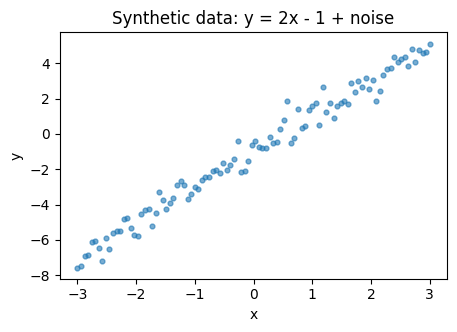

In [12]:
set_seed(0)
# Ground-truth line: y = 2x - 1, plus noise
N = 100
X = torch.linspace(-3, 3, N).unsqueeze(1)        # shape (N, 1)
true_w, true_b = 2.0, -1.0
y = true_w * X + true_b + 0.5 * torch.randn(N, 1)

plt.figure(figsize=(5, 3.2))
plt.scatter(X, y, s=12, alpha=0.6)
plt.title("Synthetic data: y = 2x - 1 + noise"); plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [13]:
# Parameters we will learn (start at 0). requires_grad=True so autograd tracks them.
w = torch.zeros(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.05
losses = []
for epoch in range(200):
    # 1) forward / predict
    y_pred = X @ w + b                       # (N,1) @ (1,1) + (1,) -> (N,1)
    # 2) loss (mean squared error)
    loss = ((y_pred - y) ** 2).mean()
    # 3) backprop: fills w.grad and b.grad
    loss.backward()
    # 4) update parameters under no_grad (this is plain SGD)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    # 5) reset grads for the next iteration (or they'd accumulate!)
    w.grad = None
    b.grad = None
    losses.append(loss.item())

print(f"learned w = {w.item():.3f} (true 2.0),  b = {b.item():.3f} (true -1.0)")

learned w = 2.000 (true 2.0),  b = -0.981 (true -1.0)


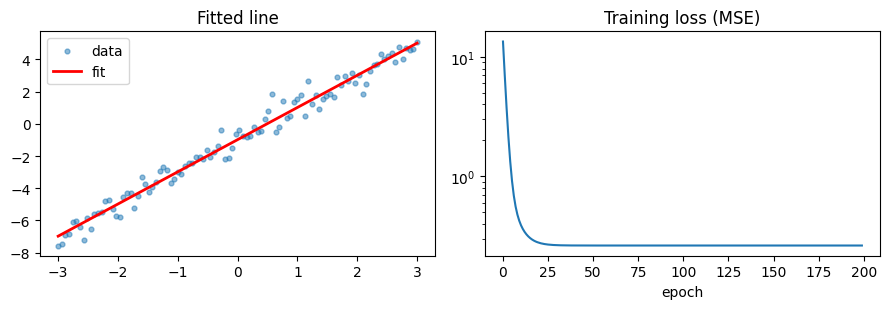

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(X, y, s=12, alpha=0.5, label="data")
with torch.no_grad():
    ax[0].plot(X, X @ w + b, "r-", lw=2, label="fit")
ax[0].set_title("Fitted line"); ax[0].legend()
ax[1].plot(losses); ax[1].set_title("Training loss (MSE)")
ax[1].set_xlabel("epoch"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()

**That's the entire essence of training.** Everything PyTorch adds on top — `nn.Module`, optimizers, `DataLoader` — is *ergonomics* around this exact loop: less boilerplate, better-tested updates (Adam, momentum), and easy batching. Next we rewrite the same model the idiomatic way.

## 4. The idiomatic way: `nn.Module`, losses, optimizers

Three abstractions replace the manual bits above:

| Manual version | PyTorch abstraction | What it gives you |
|---|---|---|
| `w`, `b` tensors | **`nn.Module`** / `nn.Linear` | parameters auto-registered & tracked |
| `((p-y)**2).mean()` | **`nn.MSELoss`**, `nn.CrossEntropyLoss`, … | tested loss functions |
| manual `w -= lr*grad` | **`torch.optim`** (SGD, Adam…) | momentum, weight decay, Adam, schedulers |

An `nn.Module` is any class subclassing `nn.Module` that (a) creates layers in `__init__` and (b) defines the data flow in `forward()`. Any `nn.Parameter` (and any sub-module) you assign as an attribute is **automatically discovered** by `.parameters()` — that's what you hand to the optimizer.

In [15]:
class LinearRegression(nn.Module):
    def __init__(self, in_features=1, out_features=1):
        super().__init__()                       # ALWAYS call this first
        self.linear = nn.Linear(in_features, out_features)  # creates weight + bias

    def forward(self, x):
        return self.linear(x)                    # call the module, never .forward() directly

model = LinearRegression().to(device)
print(model)
print("Parameters automatically tracked:")
for name, p in model.named_parameters():
    print(f"  {name:15s} shape={tuple(p.shape)}  requires_grad={p.requires_grad}")

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)   # hand params to the optimizer

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
Parameters automatically tracked:
  linear.weight   shape=(1, 1)  requires_grad=True
  linear.bias     shape=(1,)  requires_grad=True


### The canonical training loop (memorize this shape)

```python
for epoch in range(epochs):
    optimizer.zero_grad()          # 1. clear old gradients
    y_pred = model(xb)             # 2. forward pass
    loss = loss_fn(y_pred, yb)     # 3. compute loss
    loss.backward()                # 4. backprop -> fills .grad
    optimizer.step()               # 5. update parameters
```

Five lines, every time. Classification, vision, transformers — they all reuse this skeleton; only the model, data, and loss change.

In [16]:
Xd, yd = X.to(device), y.to(device)
losses = []
for epoch in range(200):
    optimizer.zero_grad()            # 1
    y_pred = model(Xd)               # 2
    loss = loss_fn(y_pred, yd)       # 3
    loss.backward()                  # 4
    optimizer.step()                 # 5
    losses.append(loss.item())

w_learned = model.linear.weight.item()
b_learned = model.linear.bias.item()
print(f"learned w={w_learned:.3f} (true 2.0), b={b_learned:.3f} (true -1.0)")
print(f"final loss: {losses[-1]:.4f}")

learned w=2.000 (true 2.0), b=-0.981 (true -1.0)
final loss: 0.2624


## 5. `Dataset` & `DataLoader`

Real training reads data in **mini-batches**, shuffled every epoch, often loaded in parallel. PyTorch splits this into two pieces:

- **`Dataset`** answers *"how many samples, and what is sample `i`?"* (`__len__`, `__getitem__`).
- **`DataLoader`** wraps a `Dataset` and handles **batching, shuffling, and parallel loading** for you.

For tensors already in memory, `TensorDataset` is the quick path. For anything custom (files on disk, on-the-fly transforms), you write your own `Dataset`.

In [17]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, y)            # pairs up X[i], y[i]
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print("samples in dataset:", len(dataset))
print("batches per epoch :", len(loader))
xb, yb = next(iter(loader))              # grab one batch
print("one batch shapes  :", xb.shape, yb.shape)

# A mini-batch training loop looks identical, just iterate the loader:
model = LinearRegression().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.05)
for epoch in range(30):
    for xb, yb in loader:                # <- batches instead of the whole dataset
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
print(f"after 30 epochs of mini-batch SGD, loss = {loss.item():.4f}")

samples in dataset: 100
batches per epoch : 7
one batch shapes  : torch.Size([16, 1]) torch.Size([16, 1])


after 30 epochs of mini-batch SGD, loss = 0.0295


In [18]:
# A custom Dataset: you control __len__ and __getitem__.
# This is where you'd load an image from disk, tokenize text, apply augmentation, etc.
class NoisyLineDataset(torch.utils.data.Dataset):
    def __init__(self, n=200):
        self.x = torch.linspace(-3, 3, n).unsqueeze(1)
        self.y = 2 * self.x - 1 + 0.5 * torch.randn(n, 1)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]      # return ONE (input, target) pair

ds = NoisyLineDataset()
print("custom dataset length:", len(ds))
print("sample 0:", ds[0])
custom_loader = DataLoader(ds, batch_size=32, shuffle=True)
print("first batch:", next(iter(custom_loader))[0].shape)

custom dataset length: 200
sample 0: (tensor([-3.]), tensor([-6.280]))
first batch: torch.Size([32, 1])


## 6. A real classifier (MLP) + regularization

Time for classification. We'll use the classic **two-moons** dataset (2 interleaving half-circles) so we can *see* the decision boundary a neural net learns. We'll build a **Multi-Layer Perceptron (MLP)**: linear layers + nonlinearities.

Key classification idioms:
- The model outputs raw **logits** (one per class). **Do not** apply softmax yourself for training.
- **`nn.CrossEntropyLoss`** expects **logits + integer class labels** and applies log-softmax internally. (This is the single most common beginner mistake — never put a `Softmax` before `CrossEntropyLoss`.)
- Predictions = `logits.argmax(dim=1)`.

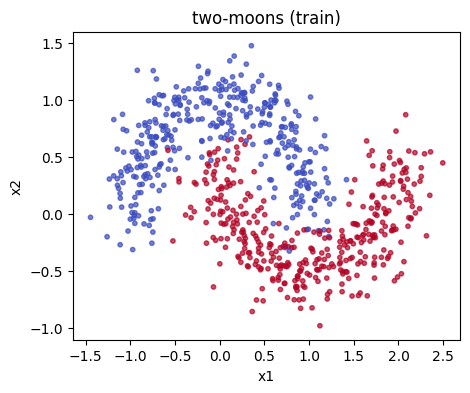

In [19]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

set_seed(42)
Xnp, ynp = make_moons(n_samples=1000, noise=0.2, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(Xnp, ynp, test_size=0.25, random_state=42)

# Convert to tensors: features float32, labels int64 (required by CrossEntropyLoss)
Xtr = torch.tensor(Xtr, dtype=torch.float32); ytr = torch.tensor(ytr, dtype=torch.long)
Xte = torch.tensor(Xte, dtype=torch.float32); yte = torch.tensor(yte, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap="coolwarm", s=10, alpha=0.7)
plt.title("two-moons (train)"); plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

In [20]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=32, n_classes=2, p_drop=0.0):
        super().__init__()
        self.net = nn.Sequential(            # Sequential = run these in order
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),              # 0.0 now; we'll use it for regularization later
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, n_classes),    # outputs raw logits (NO softmax here)
        )
    def forward(self, x):
        return self.net(x)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

model = MLP().to(device)
print(model)
print("trainable parameters:", count_params(model))

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)
trainable parameters: 1218


In [21]:
# A small reusable training helper we'll also use for the CNN later.
def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def train_classifier(model, Xtr, ytr, Xte, yte, epochs=200, lr=0.05, weight_decay=0.0, verbose=True):
    model.to(device)
    Xtr, ytr, Xte, yte = (t.to(device) for t in (Xtr, ytr, Xte, yte))
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    for epoch in range(epochs):
        # --- train mode: dropout/batchnorm behave in "training" mode ---
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()
        # --- eval mode + no_grad for honest validation metrics ---
        model.eval()
        with torch.no_grad():
            test_logits = model(Xte)
            history["train_loss"].append(loss.item())
            history["test_loss"].append(loss_fn(test_logits, yte).item())
            history["test_acc"].append(accuracy(test_logits, yte))
        if verbose and (epoch + 1) % 50 == 0:
            print(f"epoch {epoch+1:3d} | train {history['train_loss'][-1]:.3f} "
                  f"| test {history['test_loss'][-1]:.3f} | acc {history['test_acc'][-1]:.3f}")
    return history

set_seed(0)
model = MLP(hidden=32).to(device)
hist = train_classifier(model, Xtr, ytr, Xte, yte, epochs=200, lr=0.03)
print(f"\nFinal test accuracy: {hist['test_acc'][-1]:.1%}")

epoch  50 | train 0.058 | test 0.058 | acc 0.980


epoch 100 | train 0.055 | test 0.054 | acc 0.980


epoch 150 | train 0.053 | test 0.053 | acc 0.980


epoch 200 | train 0.053 | test 0.058 | acc 0.980

Final test accuracy: 98.0%


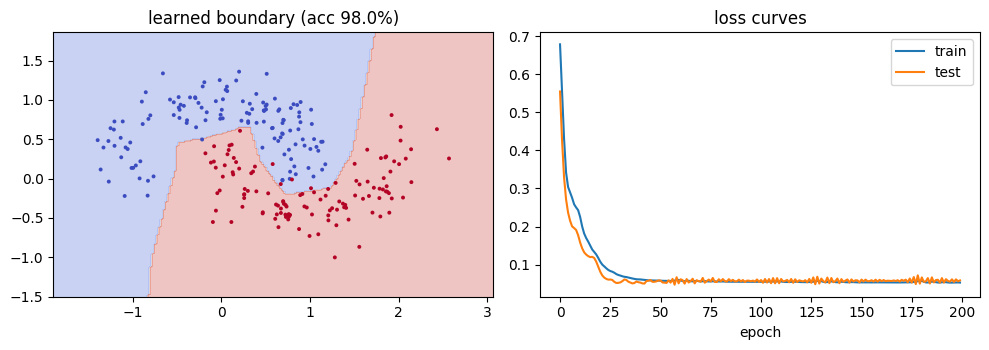

In [22]:
def plot_decision_boundary(model, X, y, ax, title):
    model.eval()
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    with torch.no_grad():
        Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8, edgecolors="none")
    ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
plot_decision_boundary(model, Xte.cpu().numpy(), yte.cpu().numpy(), ax[0],
                       f"learned boundary (acc {hist['test_acc'][-1]:.1%})")
ax[1].plot(hist["train_loss"], label="train")
ax[1].plot(hist["test_loss"], label="test")
ax[1].set_title("loss curves"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

### 6.1 Overfitting & regularization

A model with too much capacity memorizes the training noise: **train loss keeps falling while test loss rises**. PyTorch gives you several knobs to fight this; the two you'll reach for first:

- **`nn.Dropout(p)`** — randomly zeroes activations during training (only when `model.train()`), forcing redundancy.
- **Weight decay** (L2) — pass `weight_decay=...` to the optimizer to penalize large weights.

Below we deliberately overfit a too-big model on a tiny noisy subset, then add dropout + weight decay and watch the test loss behave.

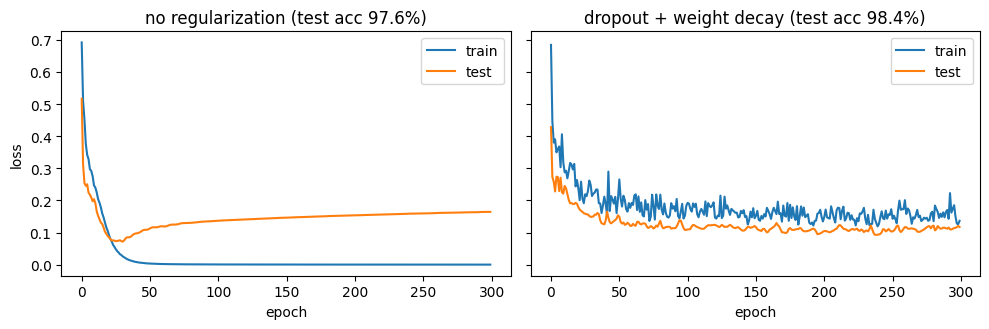

Notice: on the left, test loss turns UP (overfitting). On the right it stays flat/low.


In [23]:
set_seed(1)
# Tiny, noisy training subset -> easy to overfit
idx = torch.randperm(len(Xtr))[:60]
Xsmall, ysmall = Xtr[idx], ytr[idx]

big_plain = MLP(hidden=256, p_drop=0.0)
big_reg   = MLP(hidden=256, p_drop=0.4)

set_seed(1); h_plain = train_classifier(big_plain, Xsmall, ysmall, Xte, yte,
                                        epochs=300, lr=0.01, weight_decay=0.0, verbose=False)
set_seed(1); h_reg   = train_classifier(big_reg,   Xsmall, ysmall, Xte, yte,
                                        epochs=300, lr=0.01, weight_decay=1e-2, verbose=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
ax[0].plot(h_plain["train_loss"], label="train"); ax[0].plot(h_plain["test_loss"], label="test")
ax[0].set_title(f"no regularization (test acc {h_plain['test_acc'][-1]:.1%})"); ax[0].legend()
ax[1].plot(h_reg["train_loss"], label="train"); ax[1].plot(h_reg["test_loss"], label="test")
ax[1].set_title(f"dropout + weight decay (test acc {h_reg['test_acc'][-1]:.1%})"); ax[1].legend()
for a in ax: a.set_xlabel("epoch")
ax[0].set_ylabel("loss"); plt.tight_layout(); plt.show()
print("Notice: on the left, test loss turns UP (overfitting). On the right it stays flat/low.")

## 7. Computer vision: a Convolutional Neural Network (CNN)

For images we use **convolutional layers** (`nn.Conv2d`), which slide small learnable filters across the image — exploiting locality and sharing weights, so they need far fewer parameters than a fully-connected net.

**Image tensor convention in PyTorch is `(N, C, H, W)`**: batch, channels, height, width. Keep that order memorized — getting it wrong is a constant source of shape errors.

We'll classify the built-in **`digits`** dataset (8×8 grayscale handwritten digits, 10 classes). It's tiny, ships with scikit-learn (no download), and trains in seconds on CPU — perfect for learning the mechanics.

> 🖥️ **About `torchvision`** — In real CV work you'd use **`torchvision`** for datasets (`MNIST`, `CIFAR10`, `ImageFolder`), image **transforms/augmentation**, and **pretrained models** (ResNet, ViT…) for *transfer learning*. The canonical pattern looks like:
>
> ```python
> from torchvision import datasets, transforms, models
> tfm = transforms.Compose([transforms.ToTensor(),
>                           transforms.Normalize((0.5,), (0.5,))])
> train = datasets.MNIST(root="data", train=True, download=True, transform=tfm)
> resnet = models.resnet18(weights="IMAGENET1K_V1")   # pretrained, for transfer learning
> ```
>
> ⚠️ On *this* machine `torchvision` is installed but its version doesn't match `torch` (`operator torchvision::nms does not exist`). To use it, install a matching build, e.g.:
> ```
> pip install torchvision==0.19.1
> ```
> Until then, everything below runs **without** torchvision using the scikit-learn `digits` data.

image tensor shape (N, C, H, W): (1797, 1, 8, 8)


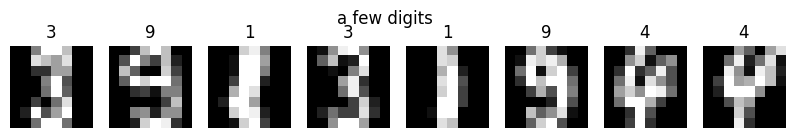

In [24]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

digits = load_digits()
X = digits.images.astype("float32") / 16.0          # pixel values 0..16 -> 0..1
X = X[:, None, :, :]                                 # add channel dim -> (N, 1, 8, 8)
yv = digits.target.astype("int64")
print("image tensor shape (N, C, H, W):", X.shape)

Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=0.2, random_state=0, stratify=yv)
train_ds = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
test_ds  = TensorDataset(torch.tensor(Xte), torch.tensor(yte))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256)

# Peek at a few images
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, Xtr, ytr):
    ax.imshow(img[0], cmap="gray"); ax.set_title(int(lab)); ax.axis("off")
plt.suptitle("a few digits"); plt.show()

In [25]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (N,1,8,8) -> (N,16,8,8)
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # -> (N,32,8,8)
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                      # -> (N,32,1,1), shape-agnostic pooling
        )
        self.classifier = nn.Linear(32, n_classes)
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)            # (N,32,1,1) -> (N,32); keep batch dim
        return self.classifier(x)

cnn = SmallCNN().to(device)
print(cnn)
print("parameters:", count_params(cnn))
# Always sanity-check shapes with a dummy batch BEFORE training:
dummy = torch.randn(4, 1, 8, 8).to(device)
print("output shape for a batch of 4:", cnn(dummy).shape)   # expect (4, 10)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=32, out_features=10, bias=True)
)
parameters: 5226
output shape for a batch of 4: torch.Size([4, 10])


In [26]:
def run_epoch(model, loader, loss_fn, opt=None):
    """One pass over `loader`. If `opt` is given -> train; else -> evaluate."""
    train = opt is not None
    model.train() if train else model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):          # grad on only while training
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * len(xb)
            total_correct += (logits.argmax(1) == yb).sum().item()
            n += len(xb)
    return total_loss / n, total_correct / n

set_seed(0)
cnn = SmallCNN().to(device)
opt = torch.optim.Adam(cnn.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(8):
    tr_loss, tr_acc = run_epoch(cnn, train_loader, loss_fn, opt)
    te_loss, te_acc = run_epoch(cnn, test_loader, loss_fn)
    print(f"epoch {epoch+1}: train acc {tr_acc:.3f} | test acc {te_acc:.3f}")
print(f"\nFinal test accuracy: {te_acc:.1%}")

epoch 1: train acc 0.350 | test acc 0.239
epoch 2: train acc 0.683 | test acc 0.536


epoch 3: train acc 0.728 | test acc 0.636


epoch 4: train acc 0.785 | test acc 0.714


epoch 5: train acc 0.824 | test acc 0.847
epoch 6: train acc 0.853 | test acc 0.864


epoch 7: train acc 0.882 | test acc 0.836
epoch 8: train acc 0.892 | test acc 0.914

Final test accuracy: 91.4%


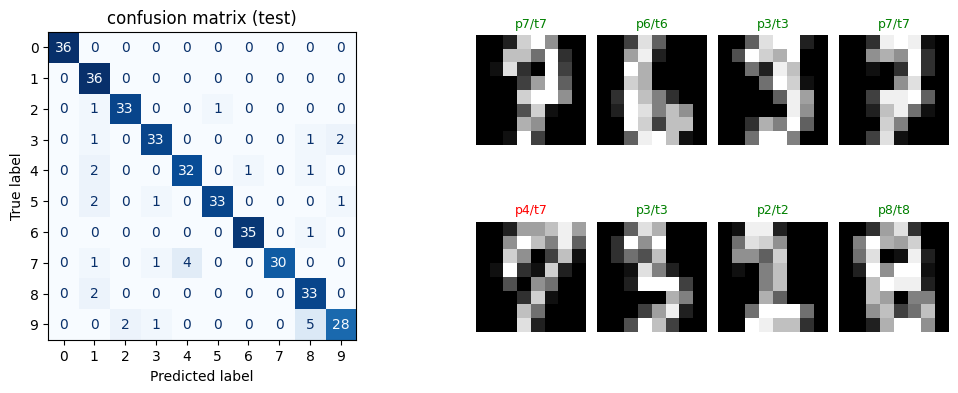

In [27]:
# Confusion matrix + a few predictions, to see WHAT the model gets wrong.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn.eval()
with torch.no_grad():
    preds = cnn(torch.tensor(Xte).to(device)).argmax(1).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(yte, preds)).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("confusion matrix (test)")

ax[1].axis("off")
sub = fig.add_gridspec(2, 4, left=0.55, right=0.98, top=0.9, bottom=0.1, wspace=0.1, hspace=0.4)
for i in range(8):
    a = fig.add_subplot(sub[i // 4, i % 4])
    a.imshow(Xte[i, 0], cmap="gray")
    ok = preds[i] == yte[i]
    a.set_title(f"p{preds[i]}/t{yte[i]}", color=("green" if ok else "red"), fontsize=9)
    a.axis("off")
plt.show()

## 8. Saving & loading models

The recommended practice is to save the **`state_dict`** (a plain dict of parameter tensors) rather than the whole pickled model object — it's portable and version-robust.

- **Save:** `torch.save(model.state_dict(), "model.pt")`
- **Load:** build the *same architecture*, then `model.load_state_dict(torch.load("model.pt"))`

For resuming training, save a **checkpoint** dict containing the model *and* optimizer state, epoch, etc.

In [28]:
import os
ckpt_dir = "checkpoints"; os.makedirs(ckpt_dir, exist_ok=True)
path = os.path.join(ckpt_dir, "small_cnn.pt")

# Save just the weights
torch.save(cnn.state_dict(), path)
print("saved state_dict with keys:", list(cnn.state_dict().keys())[:3], "...")

# Load into a fresh model of the SAME architecture
fresh = SmallCNN().to(device)
fresh.load_state_dict(torch.load(path, map_location=device))
fresh.eval()

# Verify the reloaded model gives identical predictions
with torch.no_grad():
    xb = torch.tensor(Xte[:32]).to(device)
    same = torch.equal(cnn(xb).argmax(1), fresh(xb).argmax(1))
print("reloaded model matches original predictions:", same)

# A full training checkpoint (to resume later)
checkpoint = {"epoch": 8, "model": cnn.state_dict(), "optim": opt.state_dict()}
torch.save(checkpoint, os.path.join(ckpt_dir, "checkpoint.pt"))
print("saved full checkpoint (model + optimizer + epoch)")

saved state_dict with keys: ['features.0.weight', 'features.0.bias', 'features.1.weight'] ...
reloaded model matches original predictions: True
saved full checkpoint (model + optimizer + epoch)


### 8.1 `train()` vs `eval()`, and `inference_mode`

⚠️ Two switches you must flip correctly or your metrics will be wrong:

- **`model.train()`** vs **`model.eval()`** — toggles layers that behave differently at inference, namely **Dropout** (off in eval) and **BatchNorm** (uses running stats in eval). Always call `model.eval()` before validating/predicting.
- **`torch.no_grad()` / `torch.inference_mode()`** — disable gradient tracking for a speed/memory win during inference. `inference_mode` is the newer, slightly faster version.

These are *independent*: `eval()` changes layer behavior; `no_grad`/`inference_mode` changes autograd. You typically use both together at inference.

In [29]:
m = MLP(p_drop=0.5).to(device)
x = torch.randn(1, 2).to(device)

m.train()                       # dropout ACTIVE -> stochastic outputs
outs = torch.stack([m(x) for _ in range(5)])
print("train() mode -> outputs vary (dropout on):\n", outs.squeeze().detach())

m.eval()                        # dropout DISABLED -> deterministic
with torch.inference_mode():    # fastest no-grad context for serving
    outs = torch.stack([m(x) for _ in range(5)])
print("\neval() mode -> identical every call (dropout off):\n", outs.squeeze())

train() mode -> outputs vary (dropout on):
 tensor([[ 0.416,  0.258],
        [ 0.105, -0.599],
        [ 0.577,  0.286],
        [-0.542, -0.133],
        [-0.177, -0.309]])

eval() mode -> identical every call (dropout off):
 tensor([[-0.034, -0.142],
        [-0.034, -0.142],
        [-0.034, -0.142],
        [-0.034, -0.142],
        [-0.034, -0.142]])


## 9. Sequence models: RNNs & LSTMs

Until now every input was independent. **Sequential data** — time series, audio, sensor streams, text — has *order*: an element's meaning depends on what came before. A **Recurrent Neural Network (RNN)** reads a sequence one step at a time, carrying a **hidden state** `h` that summarizes everything seen so far:

$$h_t = \tanh(W_{xh}\,x_t + W_{hh}\,h_{t-1} + b)$$

The *same* weights are reused at every step (weight sharing across time), so one small RNN handles sequences of any length.

⚠️ **The catch — vanishing/exploding gradients.** Backprop through many time steps multiplies gradients over and over, so they tend to shrink to zero (or blow up). Plain RNNs therefore struggle with **long-range** dependencies. The fix is **gated** cells:

- **LSTM** (Long Short-Term Memory) adds a separate **cell state** plus **input / forget / output gates** that learn what to store, erase, and expose — letting gradients flow across long spans.
- **GRU** (Gated Recurrent Unit) is a lighter 2-gate variant: fewer parameters, usually comparable accuracy.

LSTMs/GRUs dominated sequence modelling before the **Transformer** (next section) replaced recurrence with attention.

In [30]:
# A vanilla RNN written from scratch, to see exactly what "recurrence" means.
class RNNFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wxh = nn.Linear(input_size, hidden_size)              # input  -> hidden
        self.Whh = nn.Linear(hidden_size, hidden_size, bias=False) # hidden -> hidden (the memory)
        self.hidden_size = hidden_size

    def forward(self, x_seq):                       # x_seq: (B, T, input_size)
        B, T, _ = x_seq.shape
        h = torch.zeros(B, self.hidden_size)        # initial hidden state (all zeros)
        outputs = []
        for t in range(T):                          # walk the sequence one step at a time
            h = torch.tanh(self.Wxh(x_seq[:, t, :]) + self.Whh(h))   # <- the recurrence
            outputs.append(h)
        return torch.stack(outputs, dim=1), h       # (B,T,H) all states, (B,H) final state

set_seed(0)
toy = torch.randn(2, 5, 3)                          # (batch=2, time=5, features=3)
all_states, final_state = RNNFromScratch(3, 8)(toy)
print("hidden state at every step :", tuple(all_states.shape))   # (2, 5, 8)
print("final hidden state (summary):", tuple(final_state.shape)) # (2, 8)

hidden state at every step : (2, 5, 8)
final hidden state (summary): (2, 8)


### 9.1 PyTorch's built-in `nn.RNN`, `nn.LSTM`, `nn.GRU`

You rarely hand-roll that loop — the built-ins are heavily optimized. Their API has a few conventions that are *the* classic source of bugs:

- **Input shape** is `(batch, seq_len, features)` **only if you pass `batch_first=True`**. The default is `(seq_len, batch, features)`. ⚠️ Set `batch_first=True` and stay consistent — mismatched axes here cause silent, hard-to-find errors.
- Each module returns **two** things: `output` (the hidden state at **every** time step, shape `(B, T, H)`) and the **final** state. For `RNN`/`GRU` that final state is `h_n`; for **`LSTM` it is a tuple `(h_n, c_n)`** — hidden *and* cell state.
- `num_layers=k` stacks cells; `bidirectional=True` runs a forward and backward pass and concatenates them (so `output`'s last dim becomes `2*H`); `dropout=p` inserts dropout *between* stacked layers.

**Rule of thumb:** for **sequence-to-one** (classification, forecasting) use the *last* step / final hidden state; for **sequence-to-sequence** (tagging, translation) use the full `output`.

In [31]:
x = torch.randn(4, 6, 3)            # (batch=4, seq_len=6, features=3) -> needs batch_first=True

rnn = nn.RNN(input_size=3, hidden_size=8, num_layers=2, batch_first=True)
out, h_n = rnn(x)
print("RNN  -> output(all steps):", tuple(out.shape), "| h_n(final, per layer):", tuple(h_n.shape))

gru = nn.GRU(3, 8, batch_first=True)
out, h_n = gru(x)
print("GRU  -> output:", tuple(out.shape), "| h_n:", tuple(h_n.shape))

lstm = nn.LSTM(3, 8, batch_first=True)
out, (h_n, c_n) = lstm(x)           # NOTE the (h_n, c_n) tuple: LSTM also has a cell state
print("LSTM -> output:", tuple(out.shape), "| h_n:", tuple(h_n.shape), "| c_n:", tuple(c_n.shape))

bi = nn.LSTM(3, 8, batch_first=True, bidirectional=True)
out, _ = bi(x)
print("bidirectional -> output last dim doubles to 2*H:", tuple(out.shape))

RNN  -> output(all steps): (4, 6, 8) | h_n(final, per layer): (2, 4, 8)
GRU  -> output: (4, 6, 8) | h_n: (1, 4, 8)
LSTM -> output: (4, 6, 8) | h_n: (1, 4, 8) | c_n: (1, 4, 8)
bidirectional -> output last dim doubles to 2*H: (4, 6, 16)


### 9.2 A runnable example: time-series forecasting with an LSTM

We'll train an LSTM to forecast a signal made of two sine waves. The framing is **sequence-to-one regression**: given the last `L` values, predict the next one. We feed the LSTM's *last* time-step output into a small linear head. Afterwards we let it run **free** — feeding its own predictions back in — to generate the future, exactly like the Transformer generated text.

train windows: (1014, 50, 1) | test windows: (435, 50, 1)   # (N, L, 1)


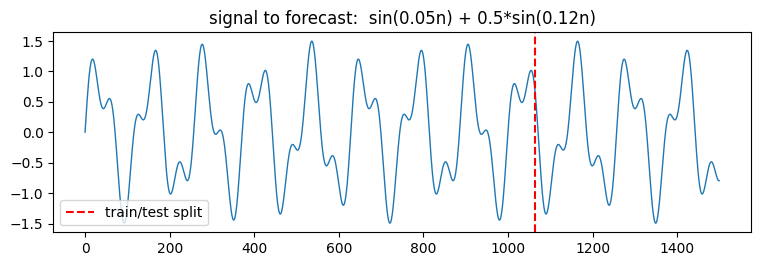

In [32]:
set_seed(0)
T = 1500
n = np.arange(T)
series = (np.sin(0.05 * n) + 0.5 * np.sin(0.12 * n)).astype("float32")   # two-frequency signal

L = 50                                              # context window length
X_all = np.stack([series[i:i + L] for i in range(T - L - 1)])   # each row: L past values
y_all = series[L:T - 1]                                          # target: the next value
split = int(0.7 * len(X_all))                       # NO shuffle: it is a time series -> split by time

to_seq = lambda a: torch.tensor(a, dtype=torch.float32).unsqueeze(-1)   # add feature dim -> (..., 1)
Xtr, ytr = to_seq(X_all[:split]).to(device), to_seq(y_all[:split]).to(device)
Xte, yte = to_seq(X_all[split:]).to(device), to_seq(y_all[split:]).to(device)
print("train windows:", tuple(Xtr.shape), "| test windows:", tuple(Xte.shape), "  # (N, L, 1)")

plt.figure(figsize=(9, 2.6))
plt.plot(series, lw=1)
plt.axvline(split + L, color="r", ls="--", label="train/test split")
plt.title("signal to forecast:  sin(0.05n) + 0.5*sin(0.12n)"); plt.legend(); plt.show()

In [33]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden=48, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden,
                            num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):                  # x: (B, L, 1)
        out, (h_n, c_n) = self.lstm(x)     # out: (B, L, hidden)
        return self.head(out[:, -1, :])    # use the LAST time step -> (B, 1)

set_seed(0)
fc = LSTMForecaster().to(device)
opt = torch.optim.Adam(fc.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()
print("LSTM forecaster parameters:", count_params(fc))

bs = 64
for epoch in range(60):
    fc.train()
    perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), bs):
        idx = perm[i:i + bs]
        opt.zero_grad()
        loss = loss_fn(fc(Xtr[idx]), ytr[idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fc.parameters(), 1.0)   # tame exploding grads (good RNN habit)
        opt.step()
    if (epoch + 1) % 20 == 0:
        fc.eval()
        with torch.no_grad():
            print(f"epoch {epoch+1:3d} | test MSE {loss_fn(fc(Xte), yte).item():.5f}")

LSTM forecaster parameters: 9841


epoch  20 | test MSE 0.00004


epoch  40 | test MSE 0.00001


epoch  60 | test MSE 0.00001


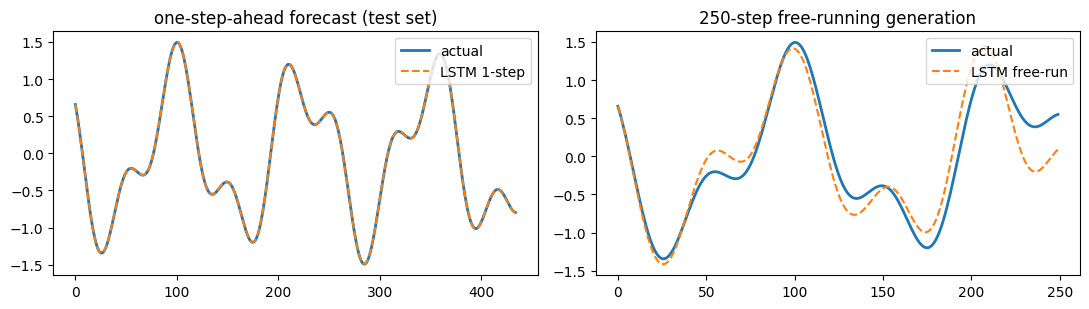

Free-running (right) tracks the true signal for hundreds of steps -> the LSTM learned the
dynamics, not just one-step copying. Eventually small errors compound and it drifts.


In [34]:
fc.eval()
with torch.no_grad():
    one_step = fc(Xte).cpu().numpy().ravel()        # one-step-ahead predictions on the test set

# Free-running generation: start from one real window, then feed predictions back in.
with torch.no_grad():
    window = Xte[0:1].clone()                        # (1, L, 1)
    rollout = []
    for _ in range(250):
        nxt = fc(window)                             # predict the next value
        rollout.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.view(1, 1, 1)], dim=1)   # slide the window
truth = series[split + L: split + L + 250]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(yte.cpu().numpy().ravel(), label="actual", lw=2)
ax[0].plot(one_step, label="LSTM 1-step", ls="--")
ax[0].set_title("one-step-ahead forecast (test set)"); ax[0].legend(loc="upper right")
ax[1].plot(truth, label="actual", lw=2)
ax[1].plot(rollout, label="LSTM free-run", ls="--")
ax[1].set_title("250-step free-running generation"); ax[1].legend(loc="upper right")
plt.tight_layout(); plt.show()
print("Free-running (right) tracks the true signal for hundreds of steps -> the LSTM learned the")
print("dynamics, not just one-step copying. Eventually small errors compound and it drifts.")

### 9.3 Practical notes

- **LSTM vs GRU vs RNN:** default to **LSTM** (or **GRU** — fewer params, often as good). Reach for a plain `nn.RNN` only for very short sequences or for teaching.
- **Gradient clipping** (`nn.utils.clip_grad_norm_`, used above) is near-mandatory for RNNs to stop exploding gradients.
- **Variable-length sequences:** real batches (e.g. sentences) have different lengths. Pad them, then wrap with `nn.utils.rnn.pack_padded_sequence` so the RNN skips the padding, and `pad_packed_sequence` to unpack — this keeps padded steps from polluting the hidden state.
- **Bidirectional** models (`bidirectional=True`) read the whole sequence both ways — great for classification/tagging, but **never** for forecasting or generation (they would peek at the future).
- **RNN vs Transformer:** RNNs are compact and stream naturally, but they process steps **sequentially** (slow to train) and still forget across very long ranges. The **Transformer** in the next section drops recurrence entirely — every position attends to every other in parallel — which is why it scaled to today's large language models.

## 10. NLP: a Transformer **from scratch**

Now the centerpiece. We'll build a tiny **GPT-style character-level language model** — the same architecture behind modern LLMs — entirely from PyTorch primitives, and train it to *generate text*. Understanding this gives you the mental model for the whole Transformer family.

The pieces, bottom-up:
1. **Token + positional embeddings** — map each character id to a vector, and add a learned position vector (attention has no inherent sense of order).
2. **Self-attention** — every position computes **queries/keys/values**; attention weights = `softmax(QKᵀ / √d)`. A **causal mask** prevents a position from "seeing" the future (so we can train next-token prediction in parallel).
3. **Multi-head attention** — run several attention "heads" in parallel and concatenate.
4. **Transformer block** — attention + a feed-forward MLP, each wrapped with a **residual connection** and **LayerNorm** (the `x = x + sublayer(norm(x))` pattern).
5. Stack blocks, project to vocabulary logits, train with **cross-entropy** on the next character.

In [35]:
# A tiny corpus. The model learns to predict the next character.
text = ("pytorch makes deep learning feel like plain python. "
        "tensors flow, gradients accumulate, and models learn. ") * 12
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}     # char -> id
itos = {i: c for c, i in stoi.items()}         # id -> char
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
block_size = 24                                # context length (how many chars the model sees)
print(f"vocab_size={vocab_size}, corpus chars={len(data)}, context window={block_size}")

def get_batch(batch_size=16):
    # Random windows; x = chars[i:i+T], y = the SAME shifted by one (next-char targets)
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch()
print("batch x shape:", xb.shape, "-> (batch, time)")

vocab_size=23, corpus chars=1272, context window=24
batch x shape: torch.Size([16, 24]) -> (batch, time)


In [36]:
class Head(nn.Module):
    """One self-attention head with a causal mask."""
    def __init__(self, d_model, head_size):
        super().__init__()
        self.key   = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        # lower-triangular matrix; registered as a buffer (saved, but not a parameter)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size
    def forward(self, x):                      # x: (B, T, d_model)
        B, T, _ = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_size)   # (B,T,T) affinities
        att = att.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # causal mask
        att = F.softmax(att, dim=-1)                                  # attention weights
        return att @ v                                                # (B,T,head_size)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.heads = nn.ModuleList([Head(d_model, d_model // n_heads) for _ in range(n_heads)])
        self.proj = nn.Linear(d_model, d_model)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)    # concat heads
        return self.proj(out)

class Block(nn.Module):
    """Transformer block: pre-LayerNorm + residual around attention and MLP."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
    def forward(self, x):
        x = x + self.attn(self.ln1(x))     # residual connection #1
        x = x + self.ff(self.ln2(x))       # residual connection #2
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)        # token embeddings
        self.pos_emb = nn.Embedding(block_size, d_model)        # positional embeddings
        self.blocks = nn.Sequential(*[Block(d_model, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)              # -> logits over vocabulary
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        x = self.ln_f(self.blocks(x))
        logits = self.head(x)                                  # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

set_seed(0)
gpt = TinyGPT(vocab_size).to(device)
print("TinyGPT parameters:", count_params(gpt))

TinyGPT parameters: 104215


In [37]:
# Train the language model: pure next-token cross-entropy.
opt = torch.optim.AdamW(gpt.parameters(), lr=3e-3)
t0 = time.time()
for step in range(400):
    xb, yb = get_batch(batch_size=32)
    _, loss = gpt(xb, yb)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d} | loss {loss.item():.3f}")
print(f"trained in {time.time()-t0:.1f}s on {device}")

step  100 | loss 0.107


step  200 | loss 0.100


step  300 | loss 0.091


step  400 | loss 0.084
trained in 11.4s on cpu


In [38]:
@torch.no_grad()
def generate(model, prompt="pytorch ", n_new=120, temperature=0.8):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(n_new):
        logits, _ = model(idx[:, -block_size:])           # only the last block_size tokens fit
        logits = logits[:, -1, :] / temperature           # focus on the final position
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # sample (not greedy) for variety
        idx = torch.cat([idx, next_id], dim=1)
    return decode(idx[0].tolist())

print("Generated text from the trained TinyGPT:\n")
print(generate(gpt, prompt="pytorch ", n_new=140))

Generated text from the trained TinyGPT:



pytorch makes deep learning feel like plain python. tensors flow, gradients accumulate, and models learn. pytorch makes deep learning feel like plai


The model learned the *style and vocabulary* of its tiny corpus from raw characters — no hand-crafted features, just attention + backprop. Scale this exact recipe (more data, bigger `d_model`/`n_layers`, longer context) and you get the architecture behind modern LLMs.

### 10.1 You don't have to write attention by hand

We built it from scratch to understand it, but PyTorch ships optimized building blocks: **`nn.MultiheadAttention`**, **`nn.TransformerEncoderLayer`**, and the fused **`F.scaled_dot_product_attention`** (which uses fast/flash kernels when available). In production, prefer these.

In [39]:
# The same idea using PyTorch's built-in encoder layer (bidirectional, no causal mask here):
layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=256,
                                   batch_first=True)        # batch_first -> (B, T, d)
encoder = nn.TransformerEncoder(layer, num_layers=2).to(device)
dummy = torch.randn(8, block_size, 64).to(device)           # (batch, seq, d_model)
print("built-in TransformerEncoder output:", encoder(dummy).shape)

# And the fused attention primitive (efficient; handles the softmax(QK^T/sqrt(d))V for you):
q = k = v = torch.randn(2, 4, block_size, 16)               # (B, heads, T, head_dim)
out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
print("scaled_dot_product_attention output:", out.shape)

built-in TransformerEncoder output: torch.Size([8, 24, 64])
scaled_dot_product_attention output: torch.Size([2, 4, 24, 16])


## 11. Expert techniques

A tour of the tools that separate a toy script from a robust training pipeline. Each is short and self-contained.

### 11.1 Learning-rate schedulers

The learning rate is the single most important hyperparameter. **Schedulers** adjust it over time — warmup then decay is standard. You call `scheduler.step()` once per epoch (or per batch for some schedulers like `OneCycleLR`).

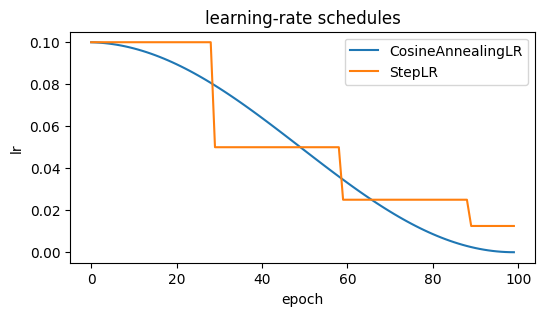

In [40]:
dummy_model = nn.Linear(10, 2)
opt = torch.optim.SGD(dummy_model.parameters(), lr=0.1)

# Cosine annealing: smoothly decay the LR following a cosine curve
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
# Step decay: multiply LR by gamma every step_size epochs
opt2 = torch.optim.SGD(dummy_model.parameters(), lr=0.1)
step = torch.optim.lr_scheduler.StepLR(opt2, step_size=30, gamma=0.5)

cos_lrs, step_lrs = [], []
for epoch in range(100):
    opt.step();  cosine.step(); cos_lrs.append(cosine.get_last_lr()[0])
    opt2.step(); step.step();   step_lrs.append(step.get_last_lr()[0])

plt.figure(figsize=(6, 3))
plt.plot(cos_lrs, label="CosineAnnealingLR")
plt.plot(step_lrs, label="StepLR")
plt.title("learning-rate schedules"); plt.xlabel("epoch"); plt.ylabel("lr"); plt.legend(); plt.show()

### 11.2 Gradient clipping & gradient accumulation

- **Gradient clipping** (`torch.nn.utils.clip_grad_norm_`) caps the gradient norm to prevent exploding gradients — essential for RNNs/Transformers. Call it **after `backward()`, before `step()`**.
- **Gradient accumulation** simulates a large batch on limited memory: run several forward/backward passes, then `step()` once. Useful when a big batch won't fit in memory (common on CPU/small GPUs).

In [41]:
model = TinyGPT(vocab_size).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)

accum_steps = 4          # effective_batch = micro_batch * accum_steps
opt.zero_grad()
for micro in range(accum_steps):
    xb, yb = get_batch(batch_size=8)
    _, loss = model(xb, yb)
    (loss / accum_steps).backward()        # scale so the accumulated grad ~ a real big-batch grad
# clip the (accumulated) gradients, then take ONE optimizer step
grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
opt.step()
print(f"took 1 optimizer step from {accum_steps} accumulated micro-batches")
print(f"gradient norm before clipping: {grad_norm:.3f} (clipped to <= 1.0)")

took 1 optimizer step from 4 accumulated micro-batches
gradient norm before clipping: 0.823 (clipped to <= 1.0)


### 11.3 Mixed precision (AMP)

> 🖥️ **GPU note** — Automatic Mixed Precision runs parts of the forward/backward pass in `float16`/`bfloat16`, giving big speed and memory savings **on a CUDA GPU**. The code below is written device-agnostically so it *runs* on CPU (with no real benefit) and *accelerates* automatically on GPU. The pattern: wrap the forward in **`torch.autocast`**, and on GPU scale the loss with a **`GradScaler`** to avoid float16 underflow.

In [42]:
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

use_amp = (device.type == "cuda")                 # AMP pays off on CUDA
scaler = torch.amp.GradScaler(enabled=use_amp)    # no-op when disabled (e.g. CPU)

xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

opt.zero_grad()
with torch.autocast(device_type=device.type, enabled=use_amp):
    logits = model(xb)
    loss = loss_fn(logits, yb)
scaler.scale(loss).backward()      # scales loss (GPU); plain backward when disabled
scaler.step(opt)                   # unscales + steps, skipping the step if inf/NaN
scaler.update()                    # adjust the scale factor for next time
print(f"AMP step complete | autocast enabled: {use_amp} | loss {loss.item():.3f}")
print("On CPU this is a normal fp32 step; on a GPU it would run in mixed precision.")

AMP step complete | autocast enabled: False | loss 2.352
On CPU this is a normal fp32 step; on a GPU it would run in mixed precision.


### 11.4 Custom layers & custom `autograd.Function`

You can define **new layers** by subclassing `nn.Module`, and even **new differentiable operations** by subclassing `torch.autograd.Function` (writing the forward *and* the backward yourself). The latter is how you'd add an op PyTorch doesn't have, or a non-standard gradient (e.g. a *straight-through estimator*).

In [43]:
# (a) A custom layer: a linear layer implemented from raw nn.Parameters.
class MyLinear(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        # nn.Parameter tells the module "track me; hand me to the optimizer"
        self.weight = nn.Parameter(torch.randn(out_f, in_f) * (in_f ** -0.5))
        self.bias = nn.Parameter(torch.zeros(out_f))
    def forward(self, x):
        return x @ self.weight.t() + self.bias

lin = MyLinear(4, 2)
print("custom layer params:", [name for name, _ in lin.named_parameters()])
print("output shape:", lin(torch.randn(3, 4)).shape)

custom layer params: ['weight', 'bias']
output shape: torch.Size([3, 2])


In [44]:
# (b) A custom autograd Function: you write forward AND backward.
# Example: a "straight-through" sign() — forward rounds to +/-1, backward pretends it was identity.
class STESign(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return torch.sign(x)                 # non-differentiable forward
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output                   # pretend gradient is 1 (straight-through)

x = torch.randn(5, requires_grad=True)
y = STESign.apply(x).sum()
y.backward()
print("input        :", x.detach())
print("sign(forward):", torch.sign(x).detach())
print("grad (STE=1) :", x.grad)              # all ones, despite sign() having zero gradient

# torch.autograd.gradcheck numerically verifies a custom backward is correct.
class Square(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x); return x * x
    @staticmethod
    def backward(ctx, g):
        (x,) = ctx.saved_tensors; return g * 2 * x

inp = (torch.randn(4, dtype=torch.double, requires_grad=True),)
print("\ngradcheck on custom Square passes:", torch.autograd.gradcheck(Square.apply, inp))

input        : tensor([ 0.066,  0.012,  0.506, -1.089,  0.323])
sign(forward): tensor([ 1.,  1.,  1., -1.,  1.])
grad (STE=1) : tensor([1., 1., 1., 1., 1.])

gradcheck on custom Square passes: True


### 11.5 `torch.compile`

In PyTorch 2.x, **`torch.compile(model)`** JIT-compiles your model into fused, optimized kernels — often a free speed-up, especially on GPU. It's one line and otherwise transparent.

⚠️ The first call is slow (it traces & compiles), and on Windows/CPU the compiler backend may be unavailable. We wrap it in `try/except` so the notebook keeps running regardless.

In [45]:
model = MLP().to(device)
try:
    compiled = torch.compile(model)              # the whole feature, one line
    out = compiled(torch.randn(8, 2).to(device)) # first call triggers compilation
    print("torch.compile worked | output:", out.shape)
except Exception as e:
    print("torch.compile not available in this environment (expected on Windows/CPU):")
    print("  ", type(e).__name__, "-", str(e).splitlines()[0][:120])
    print("On Linux + GPU this typically gives a noticeable speed-up with zero code changes.")

torch.compile not available in this environment (expected on Windows/CPU):
   BackendCompilerFailed - backend='inductor' raised:
On Linux + GPU this typically gives a noticeable speed-up with zero code changes.


### 11.6 Profiling & debugging

When training is slow or wrong, measure — don't guess. **`torch.profiler`** breaks down where time (and memory) goes per operator. For shape bugs, sprinkle `print(tensor.shape)` or assert shapes; for `NaN` losses, check the learning rate and look for `log(0)`/division by zero.

In [46]:
from torch.profiler import profile, record_function, ProfilerActivity

model = SmallCNN().to(device)
xb = torch.randn(64, 1, 8, 8).to(device)

with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    with record_function("forward_pass"):
        for _ in range(10):
            model(xb)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=6))

--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                    forward_pass        16.55%       3.644ms       100.00%      22.026ms      22.026ms             1  
                    aten::conv2d         0.63%     137.700us        39.40%       8.678ms     433.890us            20  
               aten::convolution         1.44%     317.100us        38.77%       8.540ms     427.005us            20  
              aten::_convolution         0.96%     210.700us        37.33%       8.223ms     411.150us            20  
        aten::mkldnn_convolution        35.55%       7.830ms        36.38%       8.012ms     400.615us            20  
                aten::batch_norm         0.46%  

### 11.7 Reproducibility & the bug checklist

For repeatable runs, seed everything (we have `set_seed`) and, if you need bit-exact determinism, also set:
```python
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
```

**The PyTorch debugging checklist — when results look wrong, suspect these first:**
- ❌ Forgot `optimizer.zero_grad()` → gradients accumulate, training diverges.
- ❌ Put a `Softmax` before `CrossEntropyLoss` → it expects raw logits.
- ❌ Forgot `model.eval()` at validation → Dropout/BatchNorm misbehave.
- ❌ Labels are `float`/one-hot instead of `int64` class indices for `CrossEntropyLoss`.
- ❌ Wrong tensor shape order — remember images are `(N, C, H, W)`.
- ❌ Model and data on different devices → `RuntimeError: expected ... same device`.
- ❌ Learning rate too high (loss = `NaN`/`inf`) or too low (no learning).
- ❌ Calling `loss` without `.item()` in a list → keeps the whole graph alive → memory leak.

## 12. Deployment: TorchScript & ONNX

To run a model *outside* a Python training loop (a C++ server, mobile, another runtime), you **serialize the computation graph**, not just the weights. Two standard routes:

- **TorchScript** (`torch.jit.trace` / `torch.jit.script`) — a self-contained, Python-free PyTorch program you can load in C++ (LibTorch) or a server.
- **ONNX** (`torch.onnx.export`) — an open, framework-neutral format runnable by ONNX Runtime, TensorRT, mobile/web engines, etc.

Always `model.eval()` before exporting so Dropout/BatchNorm are in inference mode.

In [47]:
model = SmallCNN().to(device).eval()
example = torch.randn(1, 1, 8, 8).to(device)

# --- TorchScript via tracing: records the ops for one example input ---
traced = torch.jit.trace(model, example)
traced.save("small_cnn_traced.pt")
reloaded = torch.jit.load("small_cnn_traced.pt")        # no model class needed to load!
with torch.no_grad():
    ok = torch.allclose(model(example), reloaded(example), atol=1e-5)
print("TorchScript reloaded model matches original:", ok)

# scripting (vs tracing) preserves control flow / if-statements:
scripted = torch.jit.script(model)
print("scripted module type:", type(scripted).__name__)

TorchScript reloaded model matches original: True
scripted module type: RecursiveScriptModule


In [48]:
# --- ONNX export (onnx is installed here, so we also verify the file) ---
onnx_path = "small_cnn.onnx"
torch.onnx.export(
    model, example, onnx_path,
    input_names=["image"], output_names=["logits"],
    dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},  # allow variable batch size
    opset_version=17,
)
import onnx
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)            # validates the exported graph
print("Exported and validated", onnx_path)
print("This file now runs in ONNX Runtime, TensorRT, mobile, or the browser — no PyTorch needed.")

Exported and validated small_cnn.onnx
This file now runs in ONNX Runtime, TensorRT, mobile, or the browser — no PyTorch needed.


## 13. Exercises & where to go next

You've gone from raw tensors to training a Transformer and exporting models for production. Cement it by *changing things and re-running*.

**🧪 Exercises (easy → hard)**
1. **Tensors:** without running it, predict the shape of `torch.randn(8, 3, 32, 32).mean(dim=(2, 3))`. Then verify. *(Hint: which axes collapse?)*
2. **Autograd:** compute the gradient of `f(x) = sin(x) * exp(x)` at `x = 1.0` with autograd and check it against the hand derivative `exp(x)*(sin(x)+cos(x))`.
3. **MLP:** in the two-moons classifier, change `hidden` to `4` and to `256`. How do the decision boundary and test accuracy change?
4. **CNN:** add a third `Conv2d` block (or a `nn.MaxPool2d`) to `SmallCNN` and see if test accuracy improves. Watch the `(N, C, H, W)` shapes.
5. **Regularization:** sweep `weight_decay` over `[0, 1e-4, 1e-2, 1e-1]` on the overfitting demo and plot final test accuracy vs. weight decay.
6. **Sequences:** in the LSTM forecaster, swap `nn.LSTM` for `nn.GRU` and for a vanilla `nn.RNN`. Compare test MSE and how long the free-running rollout stays on track — which drifts first, and why?
7. **Transformer:** increase `n_layers` to 4 and `block_size` to 48, retrain, and compare the generated text. Try `temperature` 0.3 vs 1.2 in `generate()` — what changes?
8. **From scratch:** implement an `nn.Module` for **LayerNorm** yourself and swap it into `Block`. Verify it matches `nn.LayerNorm` numerically.

**📚 Where to go next**
- **Official tutorials & docs:** https://pytorch.org/tutorials and https://pytorch.org/docs
- **Computer vision:** fix `torchvision`, then do real transfer learning with a pretrained `resnet18` on CIFAR-10.
- **NLP:** the Hugging Face `transformers` + `datasets` libraries build directly on the PyTorch you now understand.
- **Scaling up:** `torch.utils.data` workers, `DistributedDataParallel` (multi-GPU), `torch.compile`, and mixed precision on a real GPU.
- **Karpathy's "Zero to Hero"** video series — builds GPT from scratch in PyTorch (a perfect follow-on to Section 10).

**The one idea to remember:** *write the forward pass; PyTorch differentiates it.* Everything else — layers, optimizers, data loaders, schedulers — is convenience built around tensors and autograd. You now know how all of it fits together. 🎉